In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
data_path = "/content/drive/MyDrive/266-final-project/data"

print("Files in data folder:")
print(os.listdir(data_path))

Files in data folder:
['cloze_test_val__winter2018-cloze_test_ALL_val.csv', 'ROCStories_winter2017 - ROCStories_winter2017.csv']


In [7]:
for root, dirs, files in os.walk(data_path):
    print("FOLDER:", root)
    print("FILES:", files)
    print("-" * 50)

FOLDER: /content/drive/MyDrive/266-final-project/data
FILES: ['cloze_test_val__winter2018-cloze_test_ALL_val.csv', 'ROCStories_winter2017 - ROCStories_winter2017.csv']
--------------------------------------------------


In [8]:
roc_path = os.path.join(data_path, "ROCStories_winter2017 - ROCStories_winter2017.csv")
cloze_val_path = os.path.join(data_path, "cloze_test_val__winter2018-cloze_test_ALL_val.csv")

roc = pd.read_csv(roc_path)
cloze_val = pd.read_csv(cloze_val_path)

print("ROC shape:", roc.shape)
print("Cloze validation shape:", cloze_val.shape)

ROC shape: (52665, 7)
Cloze validation shape: (1571, 8)


In [9]:
print("ROC columns:")
print(roc.columns.tolist())
print()

print("Cloze validation columns:")
print(cloze_val.columns.tolist())

ROC columns:
['storyid', 'storytitle', 'sentence1', 'sentence2', 'sentence3', 'sentence4', 'sentence5']

Cloze validation columns:
['InputStoryid', 'InputSentence1', 'InputSentence2', 'InputSentence3', 'InputSentence4', 'RandomFifthSentenceQuiz1', 'RandomFifthSentenceQuiz2', 'AnswerRightEnding']


In [10]:
print("ROC preview:")
display(roc.head())

print("Cloze validation preview:")
display(cloze_val.head())

ROC preview:


,storyid,storytitle,sentence1,sentence2,sentence3,sentence4,sentence5
0,8bbe6d11-1e2e-413c-bf81-eaea05f4f1bd,David Drops the Weight,David noticed he had put on a lot of weight re...,He examined his habits to try and figure out t...,He realized he'd been eating too much fast foo...,He stopped going to burger places and started ...,"After a few weeks, he started to feel much bet..."
1,0beabab2-fb49-460e-a6e6-f35a202e3348,Frustration,Tom had a very short temper.,One day a guest made him very angry.,He punched a hole in the wall of his house.,Tom's guest became afraid and left quickly.,Tom sat on his couch filled with regret about ...
2,87da1a22-df0b-410c-b186-439700b70ba6,Marcus Buys Khakis,Marcus needed clothing for a business casual e...,All of his clothes were either too formal or t...,He decided to buy a pair of khakis.,The pair he bought fit him perfectly.,Marcus was happy to have the right clothes for...
3,2d16bcd6-692a-4fc0-8e7c-4a6f81d9efa9,Different Opinions,Bobby thought Bill should buy a trailer and ha...,Bill thought a truck would be better for what ...,Bobby pointed out two vehicles were much more ...,Bill was set in his ways with conventional thi...,He ended up buying the truck he wanted despite...
4,c71bb23b-7731-4233-8298-76ba6886cee1,Overcoming shortcomings,John was a pastor with a very bad memory.,He tried to memorize his sermons many days in ...,He decided to learn to sing to overcome his ha...,He then made all his sermons into music and sa...,His congregation was delighted and so was he.


Cloze validation preview:


,InputStoryid,InputSentence1,InputSentence2,InputSentence3,InputSentence4,RandomFifthSentenceQuiz1,RandomFifthSentenceQuiz2,AnswerRightEnding
0,138d5bfb-05cc-41e3-bf2c-fa85ebad14e2,Rick grew up in a troubled household.,"He never found good support in family, and tur...",It wasn't long before Rick got shot in a robbery.,The incident caused him to turn a new leaf.,He is happy now.,He joined a gang.,1
1,bff9f820-9605-4875-b9af-fe6f14d04256,Laverne needs to prepare something for her fri...,She decides to bake a batch of brownies.,She chooses a recipe and follows it closely.,Laverne tests one of the brownies to make sure...,The brownies are so delicious Laverne eats two...,Laverne doesn't go to her friend's party.,1
2,e8f628d5-9f97-40ed-8611-fc0e774673c4,Sarah had been dreaming of visiting Europe for...,She had finally saved enough for the trip.,She landed in Spain and traveled east across t...,She didn't like how different everything was.,Sarah then decided to move to Europe.,Sarah decided that she preferred her home over...,2
3,f5226bfe-9f26-4377-b05f-3d9568dbdec1,Gina was worried the cookie dough in the tube ...,She was very happy to find she was wrong.,The cookies from the tube were as good as from...,Gina intended to only eat 2 cookies and save t...,Gina liked the cookies so much she ate them al...,Gina gave the cookies away at her church.,1
4,69ac9b05-b956-402f-9fff-1f926ef9176b,It was my final performance in marching band.,I was playing the snare drum in the band.,We played Thriller and Radar Love.,The performance was flawless.,I was very proud of my performance.,I was very ashamed of my performance.,1


In [11]:
# Basic info
print(roc.info())
print(cloze_val.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52665 entries, 0 to 52664
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   storyid     52665 non-null  object
 1   storytitle  52665 non-null  object
 2   sentence1   52665 non-null  object
 3   sentence2   52665 non-null  object
 4   sentence3   52665 non-null  object
 5   sentence4   52665 non-null  object
 6   sentence5   52665 non-null  object
dtypes: object(7)
memory usage: 2.8+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   InputStoryid              1571 non-null   object
 1   InputSentence1            1571 non-null   object
 2   InputSentence2            1571 non-null   object
 3   InputSentence3            1571 non-null   object
 4   InputSentence4            1571 non-null   object
 5 

In [12]:
# Check missing values
print("\nROC Missing Values:\n", roc.isnull().sum())
print("\nCloze Missing Values:\n", cloze_val.isnull().sum())




ROC Missing Values:
 storyid       0
storytitle    0
sentence1     0
sentence2     0
sentence3     0
sentence4     0
sentence5     0
dtype: int64

Cloze Missing Values:
 InputStoryid                0
InputSentence1              0
InputSentence2              0
InputSentence3              0
InputSentence4              0
RandomFifthSentenceQuiz1    0
RandomFifthSentenceQuiz2    0
AnswerRightEnding           0
dtype: int64


# ROC EDA

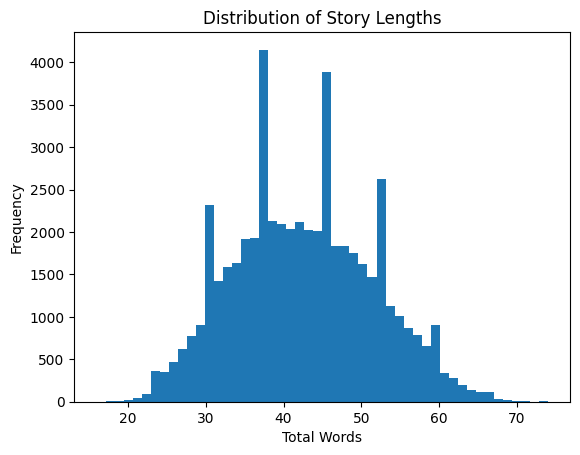

In [13]:
# Add total word count per story
roc['total_words'] = roc[['sentence1','sentence2','sentence3','sentence4','sentence5']].apply(
    lambda row: sum(len(str(s).split()) for s in row), axis=1
)

# Distribution
import matplotlib.pyplot as plt

plt.hist(roc['total_words'], bins=50)
plt.title("Distribution of Story Lengths")
plt.xlabel("Total Words")
plt.ylabel("Frequency")
plt.show()

I calculated the total number of words in each story and plotted a histogram to see how lengths vary.
This helps check if the dataset is consistent — since most stories are similar in length, models won’t be biased by unusually short or long stories.


In [14]:
# Average length per sentence position
for i in range(1,6):
    roc[f's{i}_len'] = roc[f'sentence{i}'].apply(lambda x: len(str(x).split()))

roc[[f's{i}_len' for i in range(1,6)]].mean()

,0
s1_len,7.657780
s2_len,8.566524
s3_len,8.679882
s4_len,8.571195
s5_len,9.079901


measured how long each sentence is across positions (sentence 1 to 5). This gives a sense of story structure — later sentences tend to be slightly longer, which makes sense since they often conclude the story.

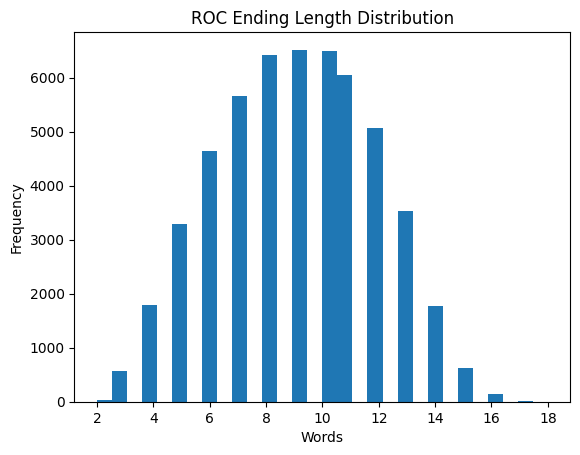

In [15]:
roc['ending_words'] = roc['sentence5'].apply(lambda x: len(str(x).split()))


plt.hist(roc['ending_words'], bins=30)
plt.title("ROC Ending Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Combine all 5 sentences into one text per story
roc['full_text'] = (
    roc['sentence1'] + " " +
    roc['sentence2'] + " " +
    roc['sentence3'] + " " +
    roc['sentence4'] + " " +
    roc['sentence5']
)

# Create CountVectorizer for bigrams
vectorizer = CountVectorizer(
    ngram_range=(2, 2),   # only bigrams
    stop_words='english', # remove common words
    max_features=20       # top 20 bigrams
)

# Fit and transform
X = vectorizer.fit_transform(roc['full_text'])

# Get bigram counts
bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

# Pair bigrams with counts and sort
bigram_freq = sorted(zip(bigrams, bigram_counts), key=lambda x: x[1], reverse=True)

# Display results
for bigram, count in bigram_freq:
    print(f"{bigram}: {count}")



didn know: 666
high school: 642
bought new: 617
didn want: 578
ice cream: 535
got home: 522
went home: 522
went store: 490
didn like: 426
great time: 406
decided make: 374
buy new: 372
long time: 362
got new: 352
year old: 350
came home: 348
decided buy: 346
worked hard: 325
needed new: 323
couldn wait: 310


The bigram analysis reveals that the dataset contains simple, everyday phrases such as “went home,” “high school,” and “worked hard.” These patterns suggest that the stories follow common real-world scenarios and exhibit a clear narrative structure involving actions and outcomes. This supports the idea that understanding the sequence of events is important for solving the task.



CLOZE VAL EDA

In [17]:
print(cloze_val['AnswerRightEnding'].value_counts())

AnswerRightEnding
1    803
2    768
Name: count, dtype: int64



I checked how often each ending (option 1 vs option 2) is correct.
This is useful to confirm the dataset is balanced, so the model can’t just guess one option and do well.


In [18]:
(cloze_val['AnswerRightEnding'] == 1).mean()

np.float64(0.5111394016549968)

I calculated how often ending 1 is correct (~51%).
This gives a simple baseline — any model we build should perform better than this.



In [19]:
# Length comparison
cloze_val['ending1_len'] = cloze_val['RandomFifthSentenceQuiz1'].apply(lambda x: len(str(x).split()))
cloze_val['ending2_len'] = cloze_val['RandomFifthSentenceQuiz2'].apply(lambda x: len(str(x).split()))

cloze_val[['ending1_len', 'ending2_len']].describe()

,ending1_len,ending2_len
count,1571.000000,1571.00000
mean,7.296626,7.40993
std,2.465013,2.53887
min,2.000000,2.00000
25%,5.000000,5.00000
50%,7.000000,7.00000
75%,9.000000,9.00000
max,14.000000,15.00000


I compared the lengths of the two candidate endings.
This ensures there’s no easy shortcut (like “longer ending = correct”), so the task actually requires understanding.



In [20]:
import re


def count_sentences(text):
    return len(re.findall(r'[.!?]+', str(text)))


cloze_val['ending1_sent_count'] = cloze_val['RandomFifthSentenceQuiz1'].apply(count_sentences)
cloze_val['ending2_sent_count'] = cloze_val['RandomFifthSentenceQuiz2'].apply(count_sentences)


print(cloze_val['ending1_sent_count'].value_counts())
print(cloze_val['ending2_sent_count'].value_counts())


ending1_sent_count
1    1566
0       5
Name: count, dtype: int64
ending2_sent_count
1    1569
0       2
Name: count, dtype: int64


In [21]:
# Show examples where ending1 has 0 sentences
cloze_val[cloze_val['ending1_sent_count'] == 0][
    ['RandomFifthSentenceQuiz1']
].head()


# # Show examples where ending2 has 0 sentences
# cloze_val[cloze_val['ending2_sent_count'] == 0][
#     ['RandomFifthSentenceQuiz2']
# ].head()


,RandomFifthSentenceQuiz1
391,"He agreed,"
1131,Cole thought about the incident every day afte...
1387,Jerry attempted to run the marathon but quickl...
1391,"They framed the letters and kept them for years,"
1552,"Paige decided to play in the snow,"


In [22]:
from collections import Counter

all_text = " ".join(
    roc['sentence1'] + " " +
    roc['sentence2'] + " " +
    roc['sentence3'] + " " +
    roc['sentence4'] + " " +
    roc['sentence5']
)

words = all_text.lower().split()
word_freq = Counter(words)

word_freq.most_common(20)

[('the', 110439),
 ('to', 88158),
 ('a', 74158),
 ('was', 63033),
 ('he', 60735),
 ('she', 49620),
 ('and', 45947),
 ('his', 34442),
 ('her', 33223),
 ('i', 26612),
 ('it', 26544),
 ('in', 25691),
 ('of', 24635),
 ('had', 23366),
 ('for', 22347),
 ('on', 17893),
 ('they', 17347),
 ('at', 13868),
 ('with', 13070),
 ('that', 11490)]

I looked at the most common words across all stories.
This helps understand the dataset’s language — but also shows that common words dominate, so raw counts aren’t very useful.




In [23]:
# Combine first 4 sentences
cloze_val['context'] = (
    cloze_val['InputSentence1'] + " " +
    cloze_val['InputSentence2'] + " " +
    cloze_val['InputSentence3'] + " " +
    cloze_val['InputSentence4']
)

cloze_val[['context', 'RandomFifthSentenceQuiz1', 'RandomFifthSentenceQuiz2']].head()

,context,RandomFifthSentenceQuiz1,RandomFifthSentenceQuiz2
0,Rick grew up in a troubled household. He never...,He is happy now.,He joined a gang.
1,Laverne needs to prepare something for her fri...,The brownies are so delicious Laverne eats two...,Laverne doesn't go to her friend's party.
2,Sarah had been dreaming of visiting Europe for...,Sarah then decided to move to Europe.,Sarah decided that she preferred her home over...
3,Gina was worried the cookie dough in the tube ...,Gina liked the cookies so much she ate them al...,Gina gave the cookies away at her church.
4,It was my final performance in marching band....,I was very proud of my performance.,I was very ashamed of my performance.


I combined the first 4 sentences into a single “context” input.
This is important because it matches how the model will actually see the data: context + possible endings.


In [24]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

Counter(filtered_words).most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('went', 10727),
 ('got', 10379),
 ('one', 9919),
 ('decided', 9066),
 ('wanted', 7380),
 ('new', 7253),
 ('it.', 6374),
 ('tom', 6329),
 ('day', 5807),
 ('would', 5503),
 ('get', 5404),
 ('took', 4944),
 ('go', 4571),
 ('found', 4532),
 ('made', 4262),
 ('told', 4147),
 ('loved', 3839),
 ('bought', 3797),
 ('could', 3631),
 ('started', 3543)]

I removed common words like “the” and “and” to focus on meaningful words.
This helps improve feature quality for models like TF-IDF.




In [25]:
# Cleaner display with correct ending text

for i in range(5):
    row = cloze_val.iloc[i]

    correct_ending = (
        row['RandomFifthSentenceQuiz1']
        if row['AnswerRightEnding'] == 1
        else row['RandomFifthSentenceQuiz2']
    )

    wrong_ending = (
        row['RandomFifthSentenceQuiz2']
        if row['AnswerRightEnding'] == 1
        else row['RandomFifthSentenceQuiz1']
    )

    print(f"\nExample {i+1}")
    print("=" * 80)
    print("Context:")
    print(row['InputSentence1'])
    print(row['InputSentence2'])
    print(row['InputSentence3'])
    print(row['InputSentence4'])
    print("\nCorrect Ending:")
    print(correct_ending)
    print("\nWrong Ending:")
    print(wrong_ending)


Example 1
Context:
Rick grew up in a troubled household.
He never found good support in family, and turned to gangs.
It wasn't long before Rick got shot in a robbery.
The incident caused him to turn a new leaf.

Correct Ending:
He is happy now.

Wrong Ending:
He joined a gang.

Example 2
Context:
Laverne needs to prepare something for her friend's party.
She decides to bake a batch of brownies.
She chooses a recipe and follows it closely.
Laverne tests one of the brownies to make sure it is delicious.

Correct Ending:
The brownies are so delicious Laverne eats two of them.

Wrong Ending:
Laverne doesn't go to her friend's party.

Example 3
Context:
Sarah had been dreaming of visiting Europe for years.
She had finally saved enough for the trip.
She landed in Spain and traveled east across the continent.
She didn't like how different everything was.

Correct Ending:
Sarah decided that she preferred her home over Europe.

Wrong Ending:
Sarah then decided to move to Europe.

Example 4
Con

Experiment 1: Lexical overlap bias

Question: Does the correct ending tend to share more words with the context than the wrong ending?

In [26]:
import re
import pandas as pd

def tokenize(text):
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)

def overlap_score(context, ending):
    c = set(tokenize(context))
    e = set(tokenize(ending))
    if len(e) == 0:
        return 0
    return len(c & e) / len(e)

# Build context
cloze_val['context'] = (
    cloze_val['InputSentence1'] + " " +
    cloze_val['InputSentence2'] + " " +
    cloze_val['InputSentence3'] + " " +
    cloze_val['InputSentence4']
)

# Overlap scores
cloze_val['overlap_e1'] = cloze_val.apply(
    lambda row: overlap_score(row['context'], row['RandomFifthSentenceQuiz1']), axis=1
)
cloze_val['overlap_e2'] = cloze_val.apply(
    lambda row: overlap_score(row['context'], row['RandomFifthSentenceQuiz2']), axis=1
)

# Correct vs wrong overlap
cloze_val['correct_overlap'] = cloze_val.apply(
    lambda row: row['overlap_e1'] if row['AnswerRightEnding'] == 1 else row['overlap_e2'],
    axis=1
)
cloze_val['wrong_overlap'] = cloze_val.apply(
    lambda row: row['overlap_e2'] if row['AnswerRightEnding'] == 1 else row['overlap_e1'],
    axis=1
)

print("Average overlap of correct ending:", cloze_val['correct_overlap'].mean())
print("Average overlap of wrong ending:", cloze_val['wrong_overlap'].mean())
print("Percent of examples where correct ending has higher overlap:",
      (cloze_val['correct_overlap'] > cloze_val['wrong_overlap']).mean())

Average overlap of correct ending: 0.44719482723938486
Average overlap of wrong ending: 0.4354723446862212
Percent of examples where correct ending has higher overlap: 0.46085295989815406



In this cell, I tested whether the correct ending shares more words with the story context than the incorrect ending. I tokenized the text, computed the overlap between context and each ending, and compared the scores.
This is useful because it checks if the dataset has a simple bias where correct endings just reuse more words from the story. If that were true, a model could perform well without actually understanding the story.


The results show that lexical overlap is not a strong signal for identifying the correct ending. This suggests that simple word-matching heuristics are insufficient, and the task requires deeper narrative understanding rather than surface-level similarity.









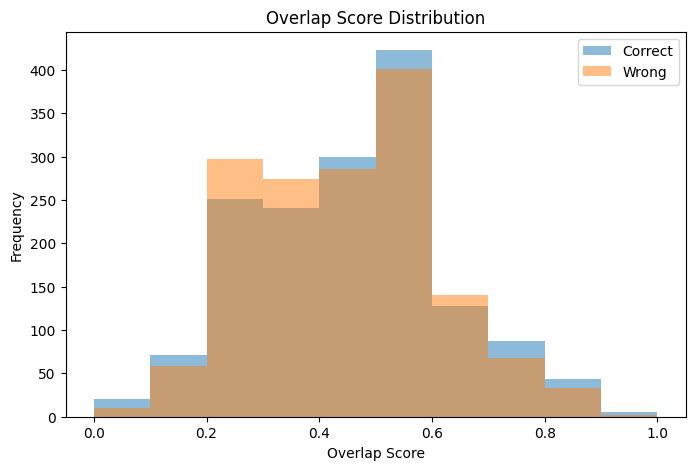

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(cloze_val['correct_overlap'], alpha=0.5, label="Correct")
plt.hist(cloze_val['wrong_overlap'], alpha=0.5, label="Wrong")
plt.legend()
plt.title("Overlap Score Distribution")
plt.xlabel("Overlap Score")
plt.ylabel("Frequency")
plt.show()



Experiment 2: Sentiment alignment bias
Question: Does the correct ending simply match the emotional tone of the context?
For example:
positive context → positive ending

negative context → negative ending

In [28]:
!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def sentiment_score(text):
    return analyzer.polarity_scores(str(text))['compound']

# Sentiment for context and endings
cloze_val['context_sent'] = cloze_val['context'].apply(sentiment_score)
cloze_val['e1_sent'] = cloze_val['RandomFifthSentenceQuiz1'].apply(sentiment_score)
cloze_val['e2_sent'] = cloze_val['RandomFifthSentenceQuiz2'].apply(sentiment_score)

# Absolute sentiment distance from context
cloze_val['dist_e1'] = (cloze_val['context_sent'] - cloze_val['e1_sent']).abs()
cloze_val['dist_e2'] = (cloze_val['context_sent'] - cloze_val['e2_sent']).abs()

cloze_val['correct_sent_dist'] = cloze_val.apply(
    lambda row: row['dist_e1'] if row['AnswerRightEnding'] == 1 else row['dist_e2'],
    axis=1
)
cloze_val['wrong_sent_dist'] = cloze_val.apply(
    lambda row: row['dist_e2'] if row['AnswerRightEnding'] == 1 else row['dist_e1'],
    axis=1
)

print("Average sentiment distance of correct ending:", cloze_val['correct_sent_dist'].mean())
print("Average sentiment distance of wrong ending:", cloze_val['wrong_sent_dist'].mean())
print("Percent where correct ending is closer in sentiment to context:",
      (cloze_val['correct_sent_dist'] < cloze_val['wrong_sent_dist']).mean())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00
Average sentiment distance of correct ending: 0.44823189051559514
Average sentiment distance of wrong ending: 0.5837452577975811
Percent where correct ending is closer in sentiment to context: 0.49331635900700194


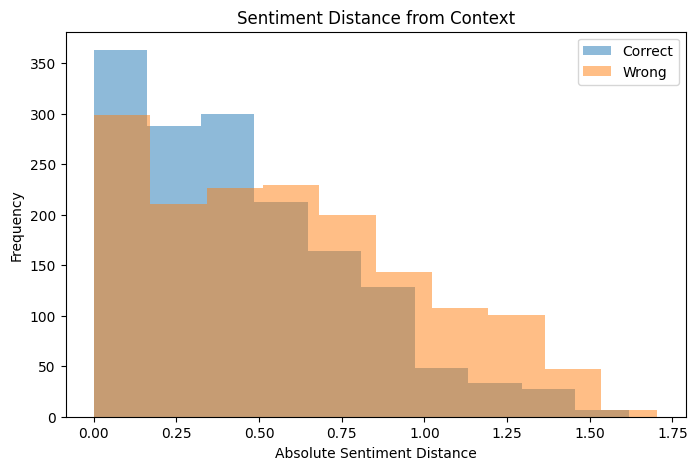

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(cloze_val['correct_sent_dist'], alpha=0.5, label="Correct")
plt.hist(cloze_val['wrong_sent_dist'], alpha=0.5, label="Wrong")
plt.legend()
plt.title("Sentiment Distance from Context")
plt.xlabel("Absolute Sentiment Distance")
plt.ylabel("Frequency")
plt.show()


A sentiment-based analysis was conducted to evaluate whether correct endings are closer in emotional tone to the story context. While correct endings show slightly lower sentiment distance on average, the difference is minimal and not consistent across examples. This indicates that sentiment alone is not a reliable signal, and deeper narrative understanding is required.



Experiment 3: Simple heuristic baseline — overlap-only model
Question: How well can a dumb rule-based model do using only overlap?

In [30]:
# Predict the ending with higher lexical overlap
cloze_val['pred_overlap'] = cloze_val.apply(
    lambda row: 1 if row['overlap_e1'] >= row['overlap_e2'] else 2,
    axis=1
)

overlap_acc = (cloze_val['pred_overlap'] == cloze_val['AnswerRightEnding']).mean()
print("Overlap-only baseline accuracy:", overlap_acc)

Overlap-only baseline accuracy: 0.5187778485041374


A simple rule-based baseline was implemented by selecting the ending with higher lexical overlap with the story context. This baseline achieved an accuracy of approximately 51.9%, which is only slightly above random guessing. This indicates that lexical overlap provides very limited predictive power and is not sufficient to solve the task.




Experiment 4: Sentiment-only baseline
Question: Can we predict the correct ending just by choosing the one closer in sentiment to the context?


In [31]:
cloze_val['pred_sentiment'] = cloze_val.apply(
    lambda row: 1 if row['dist_e1'] <= row['dist_e2'] else 2,
    axis=1
)

sentiment_acc = (cloze_val['pred_sentiment'] == cloze_val['AnswerRightEnding']).mean()
print("Sentiment-only baseline accuracy:", sentiment_acc)

Sentiment-only baseline accuracy: 0.5983450031826862


A sentiment-based baseline was implemented by selecting the ending whose sentiment is closer to that of the story context. This approach achieved an accuracy of approximately 59.8%, showing a slight improvement over random guessing. However, the performance remains relatively low, indicating that sentiment similarity alone is not a reliable predictor and cannot fully capture the reasoning required for the task.




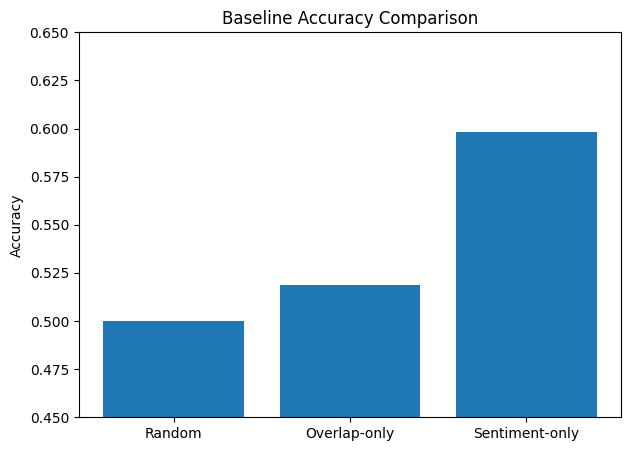

In [32]:
plt.figure(figsize=(7, 5))
labels = ["Random", "Overlap-only", "Sentiment-only"]
values = [0.5, overlap_acc, sentiment_acc]

plt.bar(labels, values)
plt.title("Baseline Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.45, 0.65)
plt.show()


Experiment 5: Sentiment-balanced subset
Create a subset where both candidate endings have similar sentiment, so choosing by positive/negative tone won’t help much.

In [33]:
# Difference in sentiment between the two candidate endings
cloze_val['ending_sent_diff'] = (cloze_val['e1_sent'] - cloze_val['e2_sent']).abs()

# Choose "hard" examples where endings have very similar sentiment
hard_sentiment = cloze_val[cloze_val['ending_sent_diff'] < 0.1].copy()

print("Number of hard sentiment examples:", len(hard_sentiment))
print("Proportion of dataset:", len(hard_sentiment) / len(cloze_val))

Number of hard sentiment examples: 390
Proportion of dataset: 0.24824952259707192


In [34]:
hard_sentiment['pred_sentiment'] = hard_sentiment.apply(
    lambda row: 1 if row['dist_e1'] <= row['dist_e2'] else 2,
    axis=1
)

hard_sent_acc = (hard_sentiment['pred_sentiment'] == hard_sentiment['AnswerRightEnding']).mean()
print("Sentiment-only accuracy on hard subset:", hard_sent_acc)

Sentiment-only accuracy on hard subset: 0.5128205128205128


In [35]:
fails = hard_sentiment[hard_sentiment['pred_sentiment'] != hard_sentiment['AnswerRightEnding']]

for i in range(min(10, len(fails))):
    row = fails.iloc[i]
    print(f"\nExample {i+1}")
    print("=" * 80)
    print("Context:")
    print(row['InputSentence1'])
    print(row['InputSentence2'])
    print(row['InputSentence3'])
    print(row['InputSentence4'])
    print("\nEnding 1:", row['RandomFifthSentenceQuiz1'])
    print("Ending 2:", row['RandomFifthSentenceQuiz2'])
    print("Correct:", row['AnswerRightEnding'])
    print("Predicted by sentiment:", row['pred_sentiment'])
    print("Context sentiment:", row['context_sent'])
    print("Ending 1 sentiment:", row['e1_sent'])
    print("Ending 2 sentiment:", row['e2_sent'])


Example 1
Context:
Sarah had been dreaming of visiting Europe for years.
She had finally saved enough for the trip.
She landed in Spain and traveled east across the continent.
She didn't like how different everything was.

Ending 1: Sarah then decided to move to Europe.
Ending 2: Sarah decided that she preferred her home over Europe.
Correct: 2
Predicted by sentiment: 1
Context sentiment: 0.1754
Ending 1 sentiment: 0.0
Ending 2 sentiment: 0.0

Example 2
Context:
Caroline was a student in medical school.
Caroline worked very hard to get good grades.
One day Caroline failed a test by one point.
Caroline was very frustrated but she continued to study hard.

Ending 1: But she gave up.
Ending 2: Later, she passed the test.
Correct: 2
Predicted by sentiment: 1
Context sentiment: -0.5413
Ending 1 sentiment: 0.0
Ending 2 sentiment: 0.0

Example 3
Context:
Sammy's coffee grinder was broken.
He needed something to crush up his coffee beans.
He put his coffee beans in a plastic bag.
He tried cru

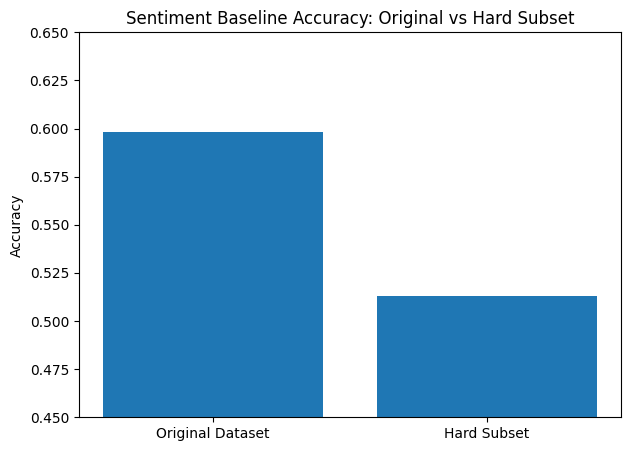

In [36]:
plt.figure(figsize=(7, 5))
labels = ["Original Dataset", "Hard Subset"]
values = [sentiment_acc, hard_sent_acc]

plt.bar(labels, values)
plt.title("Sentiment Baseline Accuracy: Original vs Hard Subset")
plt.ylabel("Accuracy")
plt.ylim(0.45, 0.65)
plt.show()


We made the task harder by removing emotional clues, and once we did that, the model basically started guessing. That means it was relying on sentiment instead of actually understanding the story.




In [37]:
import pandas as pd

rows = []

for _, row in cloze_val.iterrows():
    context = row['InputSentence1'] + " " + row['InputSentence2'] + " " + row['InputSentence3'] + " " + row['InputSentence4']

    # Ending 1
    rows.append({
        "text": context + " " + row['RandomFifthSentenceQuiz1'],
        "label": 1 if row['AnswerRightEnding'] == 1 else 0
    })

    # Ending 2
    rows.append({
        "text": context + " " + row['RandomFifthSentenceQuiz2'],
        "label": 1 if row['AnswerRightEnding'] == 2 else 0
    })

df_model = pd.DataFrame(rows)

print(df_model.head())
print(df_model['label'].value_counts())

                                                text  label
0  Rick grew up in a troubled household. He never...      1
1  Rick grew up in a troubled household. He never...      0
2  Laverne needs to prepare something for her fri...      1
3  Laverne needs to prepare something for her fri...      0
4  Sarah had been dreaming of visiting Europe for...      0
label
1    1571
0    1571
Name: count, dtype: int64


In [38]:
#Step 1: Build ROC training pairs
import pandas as pd
import numpy as np

roc = roc.reset_index(drop=True).copy()

# Build context and true ending
roc['context'] = (
    roc['sentence1'] + " " +
    roc['sentence2'] + " " +
    roc['sentence3'] + " " +
    roc['sentence4']
)
roc['true_ending'] = roc['sentence5']

# Create random negative endings by shuffling endings
rng = np.random.default_rng(42)
neg_indices = rng.permutation(len(roc))

# Avoid same-story negative ending
for i in range(len(neg_indices)):
    if neg_indices[i] == i:
        swap_with = (i + 1) % len(neg_indices)
        neg_indices[i], neg_indices[swap_with] = neg_indices[swap_with], neg_indices[i]

roc['negative_ending'] = roc.loc[neg_indices, 'true_ending'].values

# Build training rows
train_rows = []

for i, row in roc.iterrows():
    train_rows.append({
        "story_id": i,
        "context": row['context'],
        "ending": row['true_ending'],
        "text": row['context'] + " " + row['true_ending'],
        "label": 1
    })
    train_rows.append({
        "story_id": i,
        "context": row['context'],
        "ending": row['negative_ending'],
        "text": row['context'] + " " + row['negative_ending'],
        "label": 0
    })

roc_train_df = pd.DataFrame(train_rows)

print(roc_train_df.head())
print(roc_train_df['label'].value_counts())
print("Total training rows:", len(roc_train_df))

   story_id                                            context  \
0         0  David noticed he had put on a lot of weight re...   
1         0  David noticed he had put on a lot of weight re...   
2         1  Tom had a very short temper. One day a guest m...   
3         1  Tom had a very short temper. One day a guest m...   
4         2  Marcus needed clothing for a business casual e...   

                                              ending  \
0  After a few weeks, he started to feel much bet...   
1  Sara was very thankful that her mother support...   
2  Tom sat on his couch filled with regret about ...   
3                  The next day he ran his shirt on.   
4  Marcus was happy to have the right clothes for...   

                                                text  label  
0  David noticed he had put on a lot of weight re...      1  
1  David noticed he had put on a lot of weight re...      0  
2  Tom had a very short temper. One day a guest m...      1  
3  Tom had a very 

In [39]:
#Step 2: Build Cloze evaluation pairs
cloze_val = cloze_val.reset_index(drop=True).copy()

cloze_val['context'] = (
    cloze_val['InputSentence1'] + " " +
    cloze_val['InputSentence2'] + " " +
    cloze_val['InputSentence3'] + " " +
    cloze_val['InputSentence4']
)

eval_rows = []

for i, row in cloze_val.iterrows():
    eval_rows.append({
        "story_id": i,
        "context": row['context'],
        "ending": row['RandomFifthSentenceQuiz1'],
        "text": row['context'] + " " + row['RandomFifthSentenceQuiz1'],
        "label": 1 if row['AnswerRightEnding'] == 1 else 0,
        "ending_num": 1
    })
    eval_rows.append({
        "story_id": i,
        "context": row['context'],
        "ending": row['RandomFifthSentenceQuiz2'],
        "text": row['context'] + " " + row['RandomFifthSentenceQuiz2'],
        "label": 1 if row['AnswerRightEnding'] == 2 else 0,
        "ending_num": 2
    })

cloze_eval_df = pd.DataFrame(eval_rows)

print(cloze_eval_df.head())
print(cloze_eval_df['label'].value_counts())
print("Total eval rows:", len(cloze_eval_df))

   story_id                                            context  \
0         0  Rick grew up in a troubled household. He never...   
1         0  Rick grew up in a troubled household. He never...   
2         1  Laverne needs to prepare something for her fri...   
3         1  Laverne needs to prepare something for her fri...   
4         2  Sarah had been dreaming of visiting Europe for...   

                                              ending  \
0                                   He is happy now.   
1                                  He joined a gang.   
2  The brownies are so delicious Laverne eats two...   
3          Laverne doesn't go to her friend's party.   
4              Sarah then decided to move to Europe.   

                                                text  label  ending_num  
0  Rick grew up in a troubled household. He never...      1           1  
1  Rick grew up in a troubled household. He never...      0           2  
2  Laverne needs to prepare something for he

In [40]:
#Step 3: Train TF-IDF + Logistic Regression on ROC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(roc_train_df['text'])
y_train = roc_train_df['label']

X_eval = vectorizer.transform(cloze_eval_df['text'])
y_eval = cloze_eval_df['label']

tfidf_model = LogisticRegression(max_iter=1000, random_state=42)
tfidf_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
#Step 4: Evaluate properly on Cloze
import numpy as np

cloze_eval_df = cloze_eval_df.copy()
cloze_eval_df['prob'] = tfidf_model.predict_proba(X_eval)[:, 1]

story_correct = []

for story_id, group in cloze_eval_df.groupby('story_id'):
    pred_row = group.loc[group['prob'].idxmax()]
    story_correct.append(int(pred_row['label'] == 1))

tfidf_story_acc = np.mean(story_correct)
print("TF-IDF story-level accuracy:", tfidf_story_acc)

TF-IDF story-level accuracy: 0.513049013367282


### Aurelia's EDA

In [43]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def sent_token_count(text):
    text = str(text).strip()
    if not text:
        return 0
    sents = re.split(r'[.!?]+', text)
    sents = [s.strip() for s in sents if s.strip()]
    return len(sents)

def word_count(text):
    return len(tokenize(text))

def unique_word_count(text):
    return len(set(tokenize(text)))

def type_token_ratio(text):
    toks = tokenize(text)
    return len(set(toks)) / len(toks) if toks else 0

def lexical_overlap_ratio(a, b):
    a_set = set(tokenize(a))
    b_set = set(tokenize(b))
    return len(a_set & b_set) / len(b_set) if len(b_set) else 0

def jaccard_similarity(a, b):
    a_set = set(tokenize(a))
    b_set = set(tokenize(b))
    union = a_set | b_set
    return len(a_set & b_set) / len(union) if union else 0

def get_capitalized_tokens(text):
    # simple proxy for names/entities
    tokens = re.findall(r"\b[A-Z][a-z]+\b", str(text))
    return set(tokens)

def new_capitalized_entities(context, ending):
    c = get_capitalized_tokens(context)
    e = get_capitalized_tokens(ending)
    return list(e - c)

def new_entity_count(context, ending):
    return len(new_capitalized_entities(context, ending))

def contains_any(text, vocab):
    toks = set(tokenize(text))
    return int(len(toks & vocab) > 0)

def count_any(text, vocab):
    toks = tokenize(text)
    return sum(t in vocab for t in toks)

def pronoun_set():
    return {
        "he", "she", "they", "him", "her", "them",
        "his", "hers", "their", "it", "its",
        "we", "us", "our", "i", "me", "my", "you", "your"
    }

def temporal_words():
    return {
        "before", "after", "then", "finally", "later", "earlier",
        "first", "next", "last", "eventually", "soon", "suddenly",
        "already", "when", "while", "during"
    }

def causal_words():
    return {
        "because", "so", "therefore", "thus", "hence",
        "since", "as", "thereby", "consequently"
    }

def state_words():
    return {
        "opened", "closed", "lost", "found", "broke", "fixed",
        "wet", "dry", "dead", "alive", "empty", "full",
        "turned", "became", "changed", "fell", "rose",
        "arrived", "left", "sat", "stood", "put", "took",
        "gave", "got", "wearing", "holding"
    }

def negation_words():
    return {
        "not", "no", "never", "nothing", "nobody", "none",
        "didnt", "don't", "dont", "cant", "can't", "won't", "wont",
        "isnt", "isn't", "wasnt", "wasn't", "couldnt", "couldn't"
    }

PRONOUNS = pronoun_set()
TEMPORAL = temporal_words()
CAUSAL = causal_words()
STATE = state_words()
NEGATIONS = negation_words()

def feature_row(context, ending):
    return {
        "ending_words": word_count(ending),
        "ending_unique_words": unique_word_count(ending),
        "ending_ttr": type_token_ratio(ending),
        "ending_sent_count": sent_token_count(ending),
        "lexical_overlap": lexical_overlap_ratio(context, ending),
        "jaccard": jaccard_similarity(context, ending),
        "new_entity_count": new_entity_count(context, ending),
        "has_pronoun": contains_any(ending, PRONOUNS),
        "has_temporal": contains_any(ending, TEMPORAL),
        "has_causal": contains_any(ending, CAUSAL),
        "has_state_word": contains_any(ending, STATE),
        "has_negation": contains_any(ending, NEGATIONS),
        "temporal_count": count_any(ending, TEMPORAL),
        "causal_count": count_any(ending, CAUSAL),
        "state_count": count_any(ending, STATE),
        "negation_count": count_any(ending, NEGATIONS),
    }

In [44]:
# Build clean correct/wrong endings

cloze_diag = cloze_val.copy()

cloze_diag["context"] = (
    cloze_diag["InputSentence1"].astype(str) + " " +
    cloze_diag["InputSentence2"].astype(str) + " " +
    cloze_diag["InputSentence3"].astype(str) + " " +
    cloze_diag["InputSentence4"].astype(str)
)

cloze_diag["correct_ending"] = np.where(
    cloze_diag["AnswerRightEnding"] == 1,
    cloze_diag["RandomFifthSentenceQuiz1"],
    cloze_diag["RandomFifthSentenceQuiz2"]
)

cloze_diag["wrong_ending"] = np.where(
    cloze_diag["AnswerRightEnding"] == 1,
    cloze_diag["RandomFifthSentenceQuiz2"],
    cloze_diag["RandomFifthSentenceQuiz1"]
)

correct_feats = cloze_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["correct_ending"])),
    axis=1
).add_prefix("correct_")

wrong_feats = cloze_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["wrong_ending"])),
    axis=1
).add_prefix("wrong_")

cloze_diag = pd.concat([cloze_diag, correct_feats, wrong_feats], axis=1)

print(cloze_diag.shape)
cloze_diag[[
    "context", "correct_ending", "wrong_ending",
    "correct_lexical_overlap", "wrong_lexical_overlap",
    "correct_new_entity_count", "wrong_new_entity_count"
]].head()

(1571, 61)


,context,correct_ending,wrong_ending,correct_lexical_overlap,wrong_lexical_overlap,correct_new_entity_count,wrong_new_entity_count
0,Rick grew up in a troubled household. He never...,He is happy now.,He joined a gang.,0.250000,0.500000,0.0,0.0
1,Laverne needs to prepare something for her fri...,The brownies are so delicious Laverne eats two...,Laverne doesn't go to her friend's party.,0.500000,0.666667,1.0,0.0
2,Sarah had been dreaming of visiting Europe for...,Sarah decided that she preferred her home over...,Sarah then decided to move to Europe.,0.333333,0.333333,0.0,0.0
3,Gina was worried the cookie dough in the tube ...,Gina liked the cookies so much she ate them al...,Gina gave the cookies away at her church.,0.384615,0.375000,0.0,0.0
4,It was my final performance in marching band....,I was very proud of my performance.,I was very ashamed of my performance.,0.571429,0.571429,0.0,0.0


In [45]:
summary_table = pd.DataFrame({
    "correct_mean": [
        cloze_diag["correct_ending_words"].mean(),
        cloze_diag["correct_ending_ttr"].mean(),
        cloze_diag["correct_lexical_overlap"].mean(),
        cloze_diag["correct_jaccard"].mean(),
        cloze_diag["correct_new_entity_count"].mean(),
        cloze_diag["correct_has_pronoun"].mean(),
        cloze_diag["correct_has_temporal"].mean(),
        cloze_diag["correct_has_causal"].mean(),
        cloze_diag["correct_has_state_word"].mean(),
        cloze_diag["correct_has_negation"].mean(),
        cloze_diag["correct_ending_sent_count"].mean(),
    ],
    "wrong_mean": [
        cloze_diag["wrong_ending_words"].mean(),
        cloze_diag["wrong_ending_ttr"].mean(),
        cloze_diag["wrong_lexical_overlap"].mean(),
        cloze_diag["wrong_jaccard"].mean(),
        cloze_diag["wrong_new_entity_count"].mean(),
        cloze_diag["wrong_has_pronoun"].mean(),
        cloze_diag["wrong_has_temporal"].mean(),
        cloze_diag["wrong_has_causal"].mean(),
        cloze_diag["wrong_has_state_word"].mean(),
        cloze_diag["wrong_has_negation"].mean(),
        cloze_diag["wrong_ending_sent_count"].mean(),
    ]
}, index=[
    "ending_words",
    "type_token_ratio",
    "lexical_overlap",
    "jaccard_similarity",
    "new_entity_count",
    "has_pronoun_rate",
    "has_temporal_rate",
    "has_causal_rate",
    "has_state_word_rate",
    "has_negation_rate",
    "sentence_count"
])

summary_table["correct_minus_wrong"] = summary_table["correct_mean"] - summary_table["wrong_mean"]
display(summary_table.round(4))

,correct_mean,wrong_mean,correct_minus_wrong
ending_words,7.5863,7.3240,0.2623
type_token_ratio,0.9824,0.9819,0.0005
lexical_overlap,0.4472,0.4355,0.0117
jaccard_similarity,0.1021,0.0976,0.0046
new_entity_count,0.2553,0.1916,0.0637
has_pronoun_rate,0.6276,0.5767,0.0509
has_temporal_rate,0.1496,0.0980,0.0516
has_causal_rate,0.0522,0.0465,0.0057
has_state_word_rate,0.1604,0.1381,0.0223
has_negation_rate,0.0363,0.0923,-0.0560


### Aurelia's EDA

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def sent_token_count(text):
    text = str(text).strip()
    if not text:
        return 0
    sents = re.split(r'[.!?]+', text)
    sents = [s.strip() for s in sents if s.strip()]
    return len(sents)

def word_count(text):
    return len(tokenize(text))

def unique_word_count(text):
    return len(set(tokenize(text)))

def type_token_ratio(text):
    toks = tokenize(text)
    return len(set(toks)) / len(toks) if toks else 0

def lexical_overlap_ratio(a, b):
    a_set = set(tokenize(a))
    b_set = set(tokenize(b))
    return len(a_set & b_set) / len(b_set) if len(b_set) else 0

def jaccard_similarity(a, b):
    a_set = set(tokenize(a))
    b_set = set(tokenize(b))
    union = a_set | b_set
    return len(a_set & b_set) / len(union) if union else 0

def get_capitalized_tokens(text):
    # simple proxy for names/entities
    tokens = re.findall(r"\b[A-Z][a-z]+\b", str(text))
    return set(tokens)

def new_capitalized_entities(context, ending):
    c = get_capitalized_tokens(context)
    e = get_capitalized_tokens(ending)
    return list(e - c)

def new_entity_count(context, ending):
    return len(new_capitalized_entities(context, ending))

def contains_any(text, vocab):
    toks = set(tokenize(text))
    return int(len(toks & vocab) > 0)

def count_any(text, vocab):
    toks = tokenize(text)
    return sum(t in vocab for t in toks)

def pronoun_set():
    return {
        "he", "she", "they", "him", "her", "them",
        "his", "hers", "their", "it", "its",
        "we", "us", "our", "i", "me", "my", "you", "your"
    }

def temporal_words():
    return {
        "before", "after", "then", "finally", "later", "earlier",
        "first", "next", "last", "eventually", "soon", "suddenly",
        "already", "when", "while", "during"
    }

def causal_words():
    return {
        "because", "so", "therefore", "thus", "hence",
        "since", "as", "thereby", "consequently"
    }

def state_words():
    return {
        "opened", "closed", "lost", "found", "broke", "fixed",
        "wet", "dry", "dead", "alive", "empty", "full",
        "turned", "became", "changed", "fell", "rose",
        "arrived", "left", "sat", "stood", "put", "took",
        "gave", "got", "wearing", "holding"
    }

def negation_words():
    return {
        "not", "no", "never", "nothing", "nobody", "none",
        "didnt", "don't", "dont", "cant", "can't", "won't", "wont",
        "isnt", "isn't", "wasnt", "wasn't", "couldnt", "couldn't"
    }

PRONOUNS = pronoun_set()
TEMPORAL = temporal_words()
CAUSAL = causal_words()
STATE = state_words()
NEGATIONS = negation_words()

def feature_row(context, ending):
    return {
        "ending_words": word_count(ending),
        "ending_unique_words": unique_word_count(ending),
        "ending_ttr": type_token_ratio(ending),
        "ending_sent_count": sent_token_count(ending),
        "lexical_overlap": lexical_overlap_ratio(context, ending),
        "jaccard": jaccard_similarity(context, ending),
        "new_entity_count": new_entity_count(context, ending),
        "has_pronoun": contains_any(ending, PRONOUNS),
        "has_temporal": contains_any(ending, TEMPORAL),
        "has_causal": contains_any(ending, CAUSAL),
        "has_state_word": contains_any(ending, STATE),
        "has_negation": contains_any(ending, NEGATIONS),
        "temporal_count": count_any(ending, TEMPORAL),
        "causal_count": count_any(ending, CAUSAL),
        "state_count": count_any(ending, STATE),
        "negation_count": count_any(ending, NEGATIONS),
    }

In [ ]:
# Build clean correct/wrong endings

cloze_diag = cloze_val.copy()

cloze_diag["context"] = (
    cloze_diag["InputSentence1"].astype(str) + " " +
    cloze_diag["InputSentence2"].astype(str) + " " +
    cloze_diag["InputSentence3"].astype(str) + " " +
    cloze_diag["InputSentence4"].astype(str)
)

cloze_diag["correct_ending"] = np.where(
    cloze_diag["AnswerRightEnding"] == 1,
    cloze_diag["RandomFifthSentenceQuiz1"],
    cloze_diag["RandomFifthSentenceQuiz2"]
)

cloze_diag["wrong_ending"] = np.where(
    cloze_diag["AnswerRightEnding"] == 1,
    cloze_diag["RandomFifthSentenceQuiz2"],
    cloze_diag["RandomFifthSentenceQuiz1"]
)

correct_feats = cloze_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["correct_ending"])),
    axis=1
).add_prefix("correct_")

wrong_feats = cloze_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["wrong_ending"])),
    axis=1
).add_prefix("wrong_")

cloze_diag = pd.concat([cloze_diag, correct_feats, wrong_feats], axis=1)

print(cloze_diag.shape)
cloze_diag[[
    "context", "correct_ending", "wrong_ending",
    "correct_lexical_overlap", "wrong_lexical_overlap",
    "correct_new_entity_count", "wrong_new_entity_count"
]].head()

(1571, 61)


,context,correct_ending,wrong_ending,correct_lexical_overlap,wrong_lexical_overlap,correct_new_entity_count,wrong_new_entity_count
0,Rick grew up in a troubled household. He never...,He is happy now.,He joined a gang.,0.250000,0.500000,0.0,0.0
1,Laverne needs to prepare something for her fri...,The brownies are so delicious Laverne eats two...,Laverne doesn't go to her friend's party.,0.500000,0.666667,1.0,0.0
2,Sarah had been dreaming of visiting Europe for...,Sarah decided that she preferred her home over...,Sarah then decided to move to Europe.,0.333333,0.333333,0.0,0.0
3,Gina was worried the cookie dough in the tube ...,Gina liked the cookies so much she ate them al...,Gina gave the cookies away at her church.,0.384615,0.375000,0.0,0.0
4,It was my final performance in marching band....,I was very proud of my performance.,I was very ashamed of my performance.,0.571429,0.571429,0.0,0.0


This block constructs comparison features for the correct and incorrect endings so we can test whether the Story Cloze task contains shallow signals beyond true narrative reasoning.

In [ ]:
summary_table = pd.DataFrame({
    "correct_mean": [
        cloze_diag["correct_ending_words"].mean(),
        cloze_diag["correct_ending_ttr"].mean(),
        cloze_diag["correct_lexical_overlap"].mean(),
        cloze_diag["correct_jaccard"].mean(),
        cloze_diag["correct_new_entity_count"].mean(),
        cloze_diag["correct_has_pronoun"].mean(),
        cloze_diag["correct_has_temporal"].mean(),
        cloze_diag["correct_has_causal"].mean(),
        cloze_diag["correct_has_state_word"].mean(),
        cloze_diag["correct_has_negation"].mean(),
        cloze_diag["correct_ending_sent_count"].mean(),
    ],
    "wrong_mean": [
        cloze_diag["wrong_ending_words"].mean(),
        cloze_diag["wrong_ending_ttr"].mean(),
        cloze_diag["wrong_lexical_overlap"].mean(),
        cloze_diag["wrong_jaccard"].mean(),
        cloze_diag["wrong_new_entity_count"].mean(),
        cloze_diag["wrong_has_pronoun"].mean(),
        cloze_diag["wrong_has_temporal"].mean(),
        cloze_diag["wrong_has_causal"].mean(),
        cloze_diag["wrong_has_state_word"].mean(),
        cloze_diag["wrong_has_negation"].mean(),
        cloze_diag["wrong_ending_sent_count"].mean(),
    ]
}, index=[
    "ending_words",
    "type_token_ratio",
    "lexical_overlap",
    "jaccard_similarity",
    "new_entity_count",
    "has_pronoun_rate",
    "has_temporal_rate",
    "has_causal_rate",
    "has_state_word_rate",
    "has_negation_rate",
    "sentence_count"
])

summary_table["correct_minus_wrong"] = summary_table["correct_mean"] - summary_table["wrong_mean"]
display(summary_table.round(4))

,correct_mean,wrong_mean,correct_minus_wrong
ending_words,7.5863,7.3240,0.2623
type_token_ratio,0.9824,0.9819,0.0005
lexical_overlap,0.4472,0.4355,0.0117
jaccard_similarity,0.1021,0.0976,0.0046
new_entity_count,0.2553,0.1916,0.0637
has_pronoun_rate,0.6276,0.5767,0.0509
has_temporal_rate,0.1496,0.0980,0.0516
has_causal_rate,0.0522,0.0465,0.0057
has_state_word_rate,0.1604,0.1381,0.0223
has_negation_rate,0.0363,0.0923,-0.0560


This table compares average properties of correct versus wrong endings and shows whether one type systematically differs in overlap, entity continuity, or reasoning-related cues.

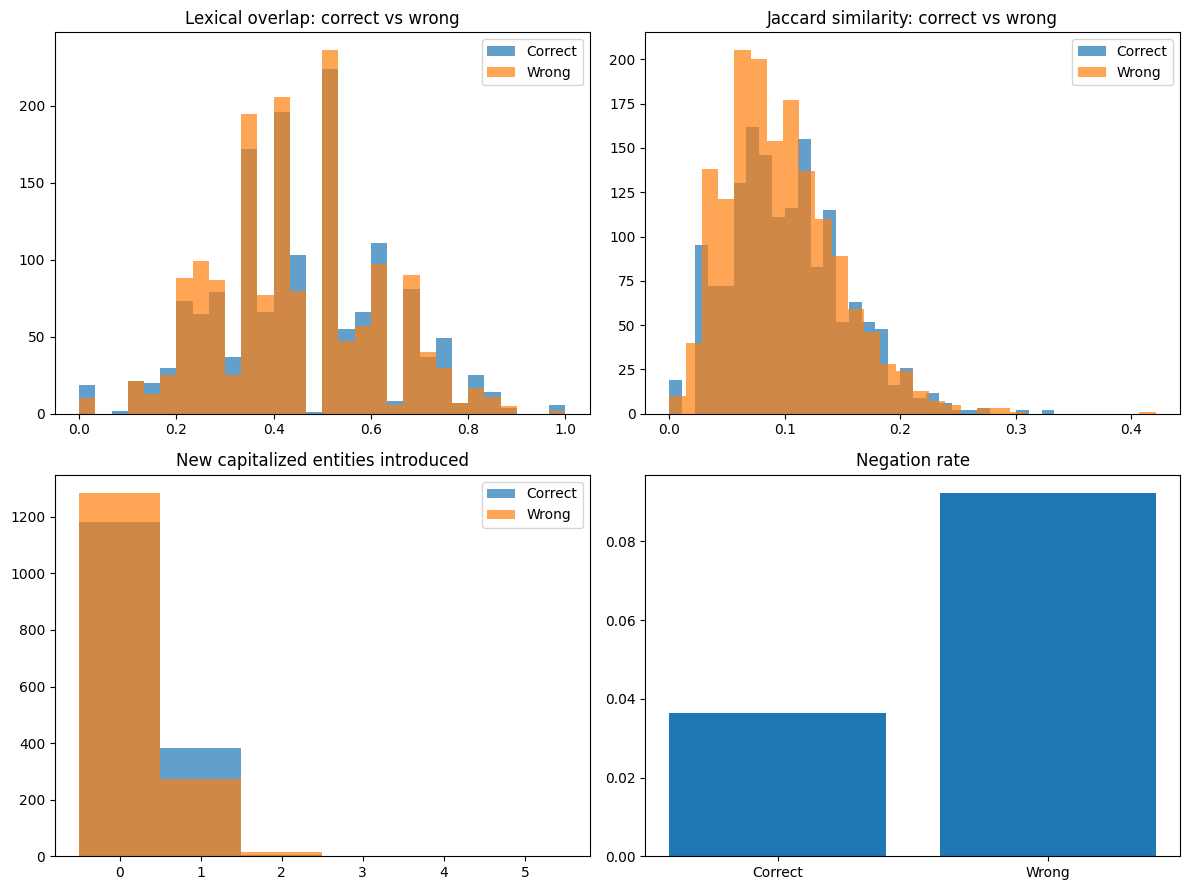

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(cloze_diag["correct_lexical_overlap"], bins=30, alpha=0.7, label="Correct")
axes[0, 0].hist(cloze_diag["wrong_lexical_overlap"], bins=30, alpha=0.7, label="Wrong")
axes[0, 0].set_title("Lexical overlap: correct vs wrong")
axes[0, 0].legend()

axes[0, 1].hist(cloze_diag["correct_jaccard"], bins=30, alpha=0.7, label="Correct")
axes[0, 1].hist(cloze_diag["wrong_jaccard"], bins=30, alpha=0.7, label="Wrong")
axes[0, 1].set_title("Jaccard similarity: correct vs wrong")
axes[0, 1].legend()

axes[1, 0].hist(cloze_diag["correct_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="Correct")
axes[1, 0].hist(cloze_diag["wrong_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="Wrong")
axes[1, 0].set_title("New capitalized entities introduced")
axes[1, 0].legend()

axes[1, 1].bar(
    ["Correct", "Wrong"],
    [
        cloze_diag["correct_has_negation"].mean(),
        cloze_diag["wrong_has_negation"].mean()
    ]
)
axes[1, 1].set_title("Negation rate")

plt.tight_layout()
plt.show()

These plots visualize how much correct and wrong endings differ on overlap, Jaccard similarity, new entity introduction, and negation, helping us see whether the task may be partly solvable through shallow heuristics

In [ ]:
roc_diag = roc.copy().reset_index(drop=True)

roc_diag["context"] = (
    roc_diag["sentence1"].astype(str) + " " +
    roc_diag["sentence2"].astype(str) + " " +
    roc_diag["sentence3"].astype(str) + " " +
    roc_diag["sentence4"].astype(str)
)
roc_diag["true_ending"] = roc_diag["sentence5"].astype(str)

# recreate the same random negative setup
rng = np.random.default_rng(42)
neg_indices = rng.permutation(len(roc_diag))
for i in range(len(neg_indices)):
    if neg_indices[i] == i:
        j = (i + 1) % len(neg_indices)
        neg_indices[i], neg_indices[j] = neg_indices[j], neg_indices[i]

roc_diag["negative_ending"] = roc_diag.loc[neg_indices, "true_ending"].values

true_feats = roc_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["true_ending"])),
    axis=1
).add_prefix("true_")

neg_feats = roc_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["negative_ending"])),
    axis=1
).add_prefix("neg_")

roc_diag = pd.concat([roc_diag, true_feats, neg_feats], axis=1)

roc_summary = pd.DataFrame({
    "true_mean": [
        roc_diag["true_lexical_overlap"].mean(),
        roc_diag["neg_lexical_overlap"].mean()
    ]
}, index=["true_overlap", "negative_overlap"])

display(roc_summary)

artifact_summary = pd.DataFrame({
    "true_mean": [
        roc_diag["true_lexical_overlap"].mean(),
        roc_diag["true_jaccard"].mean(),
        roc_diag["true_new_entity_count"].mean(),
        roc_diag["true_has_pronoun"].mean(),
        roc_diag["true_has_temporal"].mean(),
        roc_diag["true_has_causal"].mean(),
    ],
    "negative_mean": [
        roc_diag["neg_lexical_overlap"].mean(),
        roc_diag["neg_jaccard"].mean(),
        roc_diag["neg_new_entity_count"].mean(),
        roc_diag["neg_has_pronoun"].mean(),
        roc_diag["neg_has_temporal"].mean(),
        roc_diag["neg_has_causal"].mean(),
    ]
}, index=[
    "lexical_overlap",
    "jaccard",
    "new_entity_count",
    "has_pronoun_rate",
    "has_temporal_rate",
    "has_causal_rate"
])

artifact_summary["true_minus_negative"] = artifact_summary["true_mean"] - artifact_summary["negative_mean"]
display(artifact_summary.round(4))

,true_mean
true_overlap,0.387517
negative_overlap,0.177504


,true_mean,negative_mean,true_minus_negative
lexical_overlap,0.3875,0.1775,0.2100
jaccard,0.1084,0.0469,0.0615
new_entity_count,0.4286,0.9708,-0.5422
has_pronoun_rate,0.7789,0.7789,0.0000
has_temporal_rate,0.1978,0.1978,0.0000
has_causal_rate,0.0852,0.0852,0.0000


This block identifies examples that look easy from surface features alone, such as much higher overlap or fewer new entities in the correct ending.

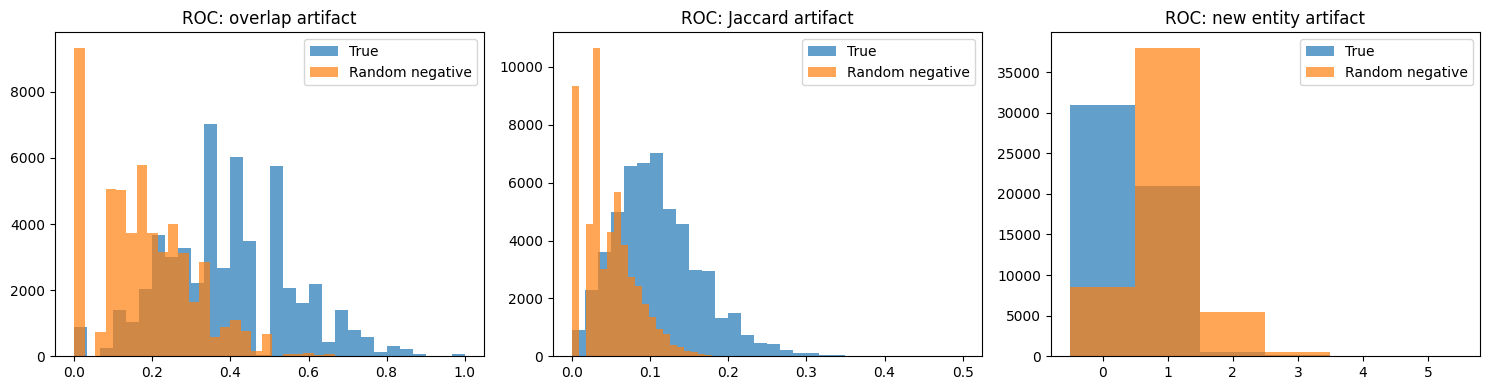

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(roc_diag["true_lexical_overlap"], bins=30, alpha=0.7, label="True")
axes[0].hist(roc_diag["neg_lexical_overlap"], bins=30, alpha=0.7, label="Random negative")
axes[0].set_title("ROC: overlap artifact")
axes[0].legend()

axes[1].hist(roc_diag["true_jaccard"], bins=30, alpha=0.7, label="True")
axes[1].hist(roc_diag["neg_jaccard"], bins=30, alpha=0.7, label="Random negative")
axes[1].set_title("ROC: Jaccard artifact")
axes[1].legend()

axes[2].hist(roc_diag["true_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="True")
axes[2].hist(roc_diag["neg_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="Random negative")
axes[2].set_title("ROC: new entity artifact")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
final_eda_summary = pd.DataFrame({
    "metric": [
        "ROC stories",
        "Story Cloze validation stories",
        "Overlap-only baseline accuracy",
        "Sentiment-only baseline accuracy",
        "Mean correct overlap",
        "Mean wrong overlap",
        "Mean correct Jaccard",
        "Mean wrong Jaccard",
        "Mean correct new entity count",
        "Mean wrong new entity count",
        # "Proportion surface-easy examples",
        # "Hard examples with weak shallow cues"
    ],
    "value": [
        len(roc_diag),
        len(cloze_diag),
        overlap_acc if "overlap_acc" in globals() else np.nan,
        sentiment_acc if "sentiment_acc" in globals() else np.nan,
        cloze_diag["correct_lexical_overlap"].mean(),
        cloze_diag["wrong_lexical_overlap"].mean(),
        cloze_diag["correct_jaccard"].mean(),
        cloze_diag["wrong_jaccard"].mean(),
        cloze_diag["correct_new_entity_count"].mean(),
        cloze_diag["wrong_new_entity_count"].mean(),
        # cloze_diag["surface_easy"].mean(),
        # len(hard_examples)
    ]
})

display(final_eda_summary)

,metric,value
0,ROC stories,52665.000000
1,Story Cloze validation stories,1571.000000
2,Overlap-only baseline accuracy,0.518778
3,Sentiment-only baseline accuracy,0.598345
4,Mean correct overlap,0.447195
5,Mean wrong overlap,0.435472
6,Mean correct Jaccard,0.102132
7,Mean wrong Jaccard,0.097571
8,Mean correct new entity count,0.255251
9,Mean wrong new entity count,0.191598


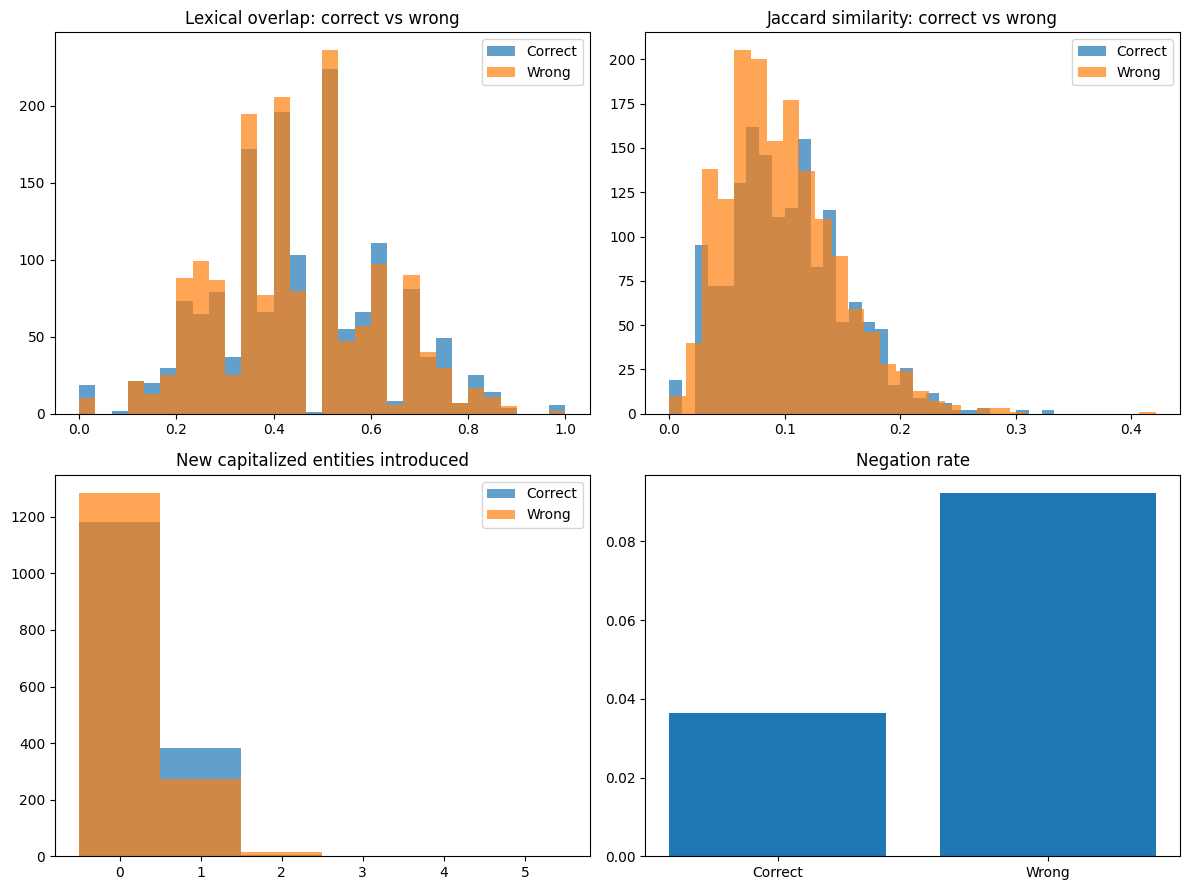

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(cloze_diag["correct_lexical_overlap"], bins=30, alpha=0.7, label="Correct")
axes[0, 0].hist(cloze_diag["wrong_lexical_overlap"], bins=30, alpha=0.7, label="Wrong")
axes[0, 0].set_title("Lexical overlap: correct vs wrong")
axes[0, 0].legend()

axes[0, 1].hist(cloze_diag["correct_jaccard"], bins=30, alpha=0.7, label="Correct")
axes[0, 1].hist(cloze_diag["wrong_jaccard"], bins=30, alpha=0.7, label="Wrong")
axes[0, 1].set_title("Jaccard similarity: correct vs wrong")
axes[0, 1].legend()

axes[1, 0].hist(cloze_diag["correct_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="Correct")
axes[1, 0].hist(cloze_diag["wrong_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="Wrong")
axes[1, 0].set_title("New capitalized entities introduced")
axes[1, 0].legend()

axes[1, 1].bar(
    ["Correct", "Wrong"],
    [
        cloze_diag["correct_has_negation"].mean(),
        cloze_diag["wrong_has_negation"].mean()
    ]
)
axes[1, 1].set_title("Negation rate")

plt.tight_layout()
plt.show()

In [48]:
roc_diag = roc.copy().reset_index(drop=True)

roc_diag["context"] = (
    roc_diag["sentence1"].astype(str) + " " +
    roc_diag["sentence2"].astype(str) + " " +
    roc_diag["sentence3"].astype(str) + " " +
    roc_diag["sentence4"].astype(str)
)
roc_diag["true_ending"] = roc_diag["sentence5"].astype(str)

# recreate the same random negative setup
rng = np.random.default_rng(42)
neg_indices = rng.permutation(len(roc_diag))
for i in range(len(neg_indices)):
    if neg_indices[i] == i:
        j = (i + 1) % len(neg_indices)
        neg_indices[i], neg_indices[j] = neg_indices[j], neg_indices[i]

roc_diag["negative_ending"] = roc_diag.loc[neg_indices, "true_ending"].values

true_feats = roc_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["true_ending"])),
    axis=1
).add_prefix("true_")

neg_feats = roc_diag.apply(
    lambda row: pd.Series(feature_row(row["context"], row["negative_ending"])),
    axis=1
).add_prefix("neg_")

roc_diag = pd.concat([roc_diag, true_feats, neg_feats], axis=1)

roc_summary = pd.DataFrame({
    "true_mean": [
        roc_diag["true_lexical_overlap"].mean(),
        roc_diag["neg_lexical_overlap"].mean()
    ]
}, index=["true_overlap", "negative_overlap"])

display(roc_summary)

artifact_summary = pd.DataFrame({
    "true_mean": [
        roc_diag["true_lexical_overlap"].mean(),
        roc_diag["true_jaccard"].mean(),
        roc_diag["true_new_entity_count"].mean(),
        roc_diag["true_has_pronoun"].mean(),
        roc_diag["true_has_temporal"].mean(),
        roc_diag["true_has_causal"].mean(),
    ],
    "negative_mean": [
        roc_diag["neg_lexical_overlap"].mean(),
        roc_diag["neg_jaccard"].mean(),
        roc_diag["neg_new_entity_count"].mean(),
        roc_diag["neg_has_pronoun"].mean(),
        roc_diag["neg_has_temporal"].mean(),
        roc_diag["neg_has_causal"].mean(),
    ]
}, index=[
    "lexical_overlap",
    "jaccard",
    "new_entity_count",
    "has_pronoun_rate",
    "has_temporal_rate",
    "has_causal_rate"
])

artifact_summary["true_minus_negative"] = artifact_summary["true_mean"] - artifact_summary["negative_mean"]
display(artifact_summary.round(4))

,true_mean
true_overlap,0.387517
negative_overlap,0.177504


,true_mean,negative_mean,true_minus_negative
lexical_overlap,0.3875,0.1775,0.2100
jaccard,0.1084,0.0469,0.0615
new_entity_count,0.4286,0.9708,-0.5422
has_pronoun_rate,0.7789,0.7789,0.0000
has_temporal_rate,0.1978,0.1978,0.0000
has_causal_rate,0.0852,0.0852,0.0000


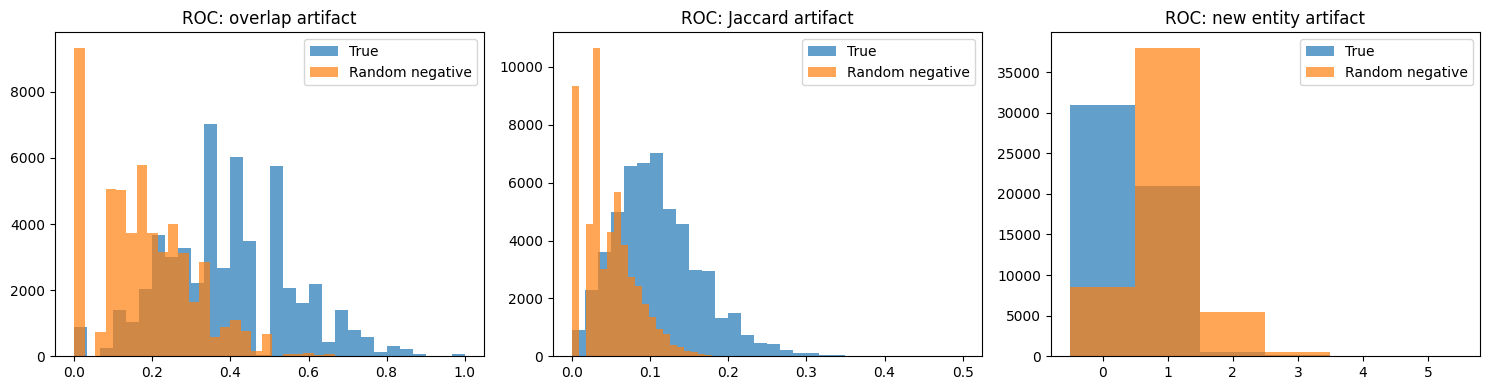

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(roc_diag["true_lexical_overlap"], bins=30, alpha=0.7, label="True")
axes[0].hist(roc_diag["neg_lexical_overlap"], bins=30, alpha=0.7, label="Random negative")
axes[0].set_title("ROC: overlap artifact")
axes[0].legend()

axes[1].hist(roc_diag["true_jaccard"], bins=30, alpha=0.7, label="True")
axes[1].hist(roc_diag["neg_jaccard"], bins=30, alpha=0.7, label="Random negative")
axes[1].set_title("ROC: Jaccard artifact")
axes[1].legend()

axes[2].hist(roc_diag["true_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="True")
axes[2].hist(roc_diag["neg_new_entity_count"], bins=np.arange(-0.5, 6.5, 1), alpha=0.7, label="Random negative")
axes[2].set_title("ROC: new entity artifact")
axes[2].legend()

plt.tight_layout()
plt.show()

In [54]:
final_eda_summary = pd.DataFrame({
    "metric": [
        "ROC stories",
        "Story Cloze validation stories",
        "Overlap-only baseline accuracy",
        "Sentiment-only baseline accuracy",
        "Mean correct overlap",
        "Mean wrong overlap",
        "Mean correct Jaccard",
        "Mean wrong Jaccard",
        "Mean correct new entity count",
        "Mean wrong new entity count",
        # "Proportion surface-easy examples",
        # "Hard examples with weak shallow cues"
    ],
    "value": [
        len(roc_diag),
        len(cloze_diag),
        overlap_acc if "overlap_acc" in globals() else np.nan,
        sentiment_acc if "sentiment_acc" in globals() else np.nan,
        cloze_diag["correct_lexical_overlap"].mean(),
        cloze_diag["wrong_lexical_overlap"].mean(),
        cloze_diag["correct_jaccard"].mean(),
        cloze_diag["wrong_jaccard"].mean(),
        cloze_diag["correct_new_entity_count"].mean(),
        cloze_diag["wrong_new_entity_count"].mean(),
        # cloze_diag["surface_easy"].mean(),
        # len(hard_examples)
    ]
})

display(final_eda_summary)

,metric,value
0,ROC stories,52665.000000
1,Story Cloze validation stories,1571.000000
2,Overlap-only baseline accuracy,0.518778
3,Sentiment-only baseline accuracy,0.598345
4,Mean correct overlap,0.447195
5,Mean wrong overlap,0.435472
6,Mean correct Jaccard,0.102132
7,Mean wrong Jaccard,0.097571
8,Mean correct new entity count,0.255251
9,Mean wrong new entity count,0.191598


The main takeaway is that the Story Cloze validation set does contain some shallow signals, but they are fairly weak. Correct endings have only slightly higher lexical overlap and Jaccard similarity than wrong endings, so overlap alone does not separate them very well. The strongest single pattern is actually negation: wrong endings use negation more often, which suggests that some incorrect endings may sound contradictory in a somewhat surface-level way. Correct endings also show slightly more pronouns, temporal cues, and state-related words, which fits the idea that good endings tend to continue the narrative flow more naturally.

The ROC random-negative analysis is where the artifact story becomes much stronger. True endings have much higher overlap with their contexts than randomly shuffled negative endings, and random negatives introduce far more new entities. That means if you train with naive random negatives, the task can become artificially easy because the model can often spot mismatches without doing real temporal, causal, or state-tracking reasoning. So overall, your EDA supports the project motivation well: Story Cloze itself is not dominated by overlap shortcuts, but randomly constructed ROC negatives clearly are, which justifies building more controlled negative examples for your actual experiments

We then move to a modeling approach. Using the ROCStories dataset, we construct a training set by pairing each story context with both its correct ending (positive example) and a randomly shuffled incorrect ending (negative example). This allows us to frame the task as a binary classification problem.
For evaluation, we convert the Story Cloze dataset into a similar format by treating each candidate ending separately with a binary label. We then train a TF-IDF + Logistic Regression model, which captures surface-level word patterns and n-gram features.
At test time, for each story, the model assigns probabilities to both candidate endings, and we select the ending with the higher probability. However, the model achieves only ~51% accuracy, which is essentially random performance.


